$$\text{\textbf{\Large Simulación Numérica del Sistema Esfera-Riel}}$$
$$\text{\small Método de Runge-Kutta de Cuarto Orden (RK4)}$$

$$\text{\textbf{\large Importación de Librerías y Dependencias}}$$

In [19]:
# RK4 Sistema Esfera - Riel
%matplotlib inline

from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.patches as patches

$$\text{\textbf{\large Definición de Parámetros Físicos y Constantes del Sistema}}$$

In [20]:
#Declaracion constantes Fisicas
r = 0.018 # Radio de la esfera en [m]
m = 0.27 # Masa de la esfera en [kg]
Ib = 4.32e-5 # Momento de inercia de la esfera [kg * m^2]
M = 1.122 # Masa del riel en [kg]
lw = 0.50 # Radio del riel en [m]
Iw = 14.025e-2 # Momento de inercia del riel en [kg * m^2]
l = 0.49 # Distancia de alicacion de la fuerza
b = 1.0 # Friccion del sistema conductor en [N * s / m]
K = 0.001 # Constante de resorte del sistema conductor en [N/m]
g = 9.81 # Constante de aceleracion gravitatoria en [m / s^2]

$$\text{\textbf{\large Cálculo de Coeficientes y Constantes Auxiliares ($a_i$, $b_i$)}}$$

In [21]:
# Constantes auxiliares para el sistema de ecuaciones de movimiento
a1 = m + (Ib / r**2 )
a2 = m*r + (Ib / r)
a3 = m*g

b1 = Ib + Iw + m * r**2
b2 = 2 * m
b3 = b * l**2
b4 = K * l**2
b5 = m * r + (Ib / r)
b6 = m * g

$$\text{\textbf{\large Funcion que representa la fuerza aplicada sobre la viga mediante el motor}}$$

In [22]:
def u(t):
    #Caso 1.1
    return 0.0

    #Caso 1.2
    #return m*g

    #Caso 2
    #return 0.0005

    #Caso 3
    #return 1.63

$$\text{\textbf{\large Datos del Problema y Condiciones Iniciales}}$$

In [23]:
h = 0.001
t0 = 0
tn = 50
#Caso 1.1 y Caso 2:
x0 = np.array([0, 0, 0, 0]) # Esfera sin desplazar del centro [Posicion en x]

#Caso 1.2:
#x0 = np.array([-0.49, 0, 0, 0]) # Esfera desplazada 49[cm] a la izquierda [Posicion en x]

#Caso 3:
#x0 = np.array([-0.30, 0, 0, 0]) # Esfera desplazada 30[cm] a la izquierda [Posicion en x]

n = int(np.round((tn-t0)/h,0))

$$\text{\textbf{\large Representación en el Espacio de Estados}}$$
$$\begin{array}{l}
\bullet \ \dot{x}_1 = x_2 \\
\bullet \ \dot{x}_2 = \frac{\text{Numerador}}{\text{Denominador}} \\
\quad \bullet \ \text{Numerador} = a_2 \left[ (b_2 x_1 x_2 + b_3)x_4 + b_4 x_3 - b_6 x_1 \cos(x_3) \right] + (m x_1^2 + b_1)(a_3 \sin(x_3) + m x_1 x_4^2) - a_2 l \cos(x_3)u(t) \\
\quad \bullet \ \text{Denominador} = a_1 (m x_1^2 + b_1) - a_2 b_5 \\
\bullet \ \dot{x}_3 = x_4 \\
\bullet \ \dot{x}_4 = x_{4\text{part1}} - x_{4\text{part2}} - x_{4\text{part3}} + x_{4\text{part4}} \\
\quad \bullet \ \text{x}_{4\text{part1}} = \frac{-(b_2 x_1 x_2 + b_3)x_4 - b_4 x_3 + b_6 x_1 \cos(x_3)}{m x_1^2 + b_1} \\
\quad \bullet \ \text{x}_{4\text{part2}} = \frac{b_5 (a_3 \sin(x_3) + m x_1 x_4^2)}{a_1(m x_1^2 + b_1) - a_2 b_5} \\
\quad \bullet \ \text{x}_{4\text{part3}} = \frac{a_2 b_5 \left[ (b_2 x_1 x_2 + b_3)x_4 + b_4 x_3 - b_6 x_1 \cos(x_3) \right]}{(m x_1^2 + b_1)(a_1(m x_1^2 + b_1) - a_2 b_5)} \\
\quad \bullet \ \text{x}_{4\text{part4}} = \left( 1 + \frac{a_2 b_5}{a_1 (m x_1^2 + b_1) - a_2 b_5} \right) \left( \frac{l \cos(x_3) u(t)}{m x_1^2 + b_1} \right)
\end{array}$$

In [24]:
#Funcion de representacion en el espacio de estados
def f(t, x):
    x1 = x[0]  # Posicion de la esfera
    x2 = x[1]  # Velocidad de la esfera
    x3 = x[2]  # Angulo del riel
    x4 = x[3]  # Velocidad angular del riel

    # Derivadas del sistema Esfera-Riel
    x1prima = x2

    x2primaNum = a2 * ( ( b2*x1*x2 + b3 ) * x4 + b4 * x3 - b6 * x1 * np.cos(x3)) + (m * x1**2 + b1) * (a3*np.sin(x3) + m * x1 * x4**2) - a2 * l * np.cos(x3) * u(t)
    x2primaDenom = a1*(m*x1**2 + b1) - a2 * b5
    x2prima = x2primaNum / x2primaDenom

    x3prima = x4

    x4pter1 =  (-(b2 * x1 * x2 + b3)*x4 - b4*x3 + b6 * x1 * np.cos(x3) ) / (m * x1**2 + b1)
    x4pter2 =  ( b5 * (a3 * np.sin(x3) + m * x1 * x4**2) ) / ( a1*(m * x1**2 + b1) - a2 * b5 )
    x4pter3 = (a2*b5 * ( (b2 * x1 * x2 + b3)*x4 + b4*x3 - b6 * x1 * np.cos(x3)))/( (m * x1**2 + b1) * (a1*(m * x1**2 + b1) - a2 * b5) )
    x4pter4 = (1 + (a2 * b5) / ( a1 * (m * x1**2 + b1) - a2 * b5)) * ( ( l * np.cos(x3) * u(t)) / ( m * x1**2 + b1 ) )

    x4prima = x4pter1 - x4pter2 - x4pter3 + x4pter4

    # Retorno del vector de cambio corregido
    return np.array([x1prima, x2prima, x3prima, x4prima])

## Preparación de los datos y el tiempo para la simulación

Antes de meter las ecuaciones al ciclo que resuelve el sistema, necesitamos armar los arreglos en donde vamos a guardar todos los datos que vaya calculando Python. Esto lo hacemos en tres pasos sencillos:

### 1. Vector de tiempo (`t_valores`)
Creamos una línea del tiempo que va desde el segundo `t0` hasta el segundo `tn`. Usamos el tamaño de paso $h = 0.001$ segundos para que los puntos estén muy pegaditos. Esto nos da un total de $n+1$ puntos que servirán como el eje X de nuestras gráficas.

### 2. Matriz para guardar los estados (`x_valores`)
Para no saturar la memoria dentro del ciclo, creamos desde antes una matriz llena de ceros usando NumPy. Esta matriz tiene $n+1$ filas (una para cada instante de tiempo) y 4 columnas. Cada columna guarda el comportamiento de una variable del sistema:
* **Columna 0:** Posición de la esfera ($x_1$) en metros.
* **Columna 1:** Velocidad de la esfera ($x_2$) en m/s.
* **Columna 2:** Ángulo del riel ($x_3$) en radianes.
* **Columna 3:** Velocidad angular del riel ($x_4$) en rad/s.

### 3. Condiciones iniciales
Metemos nuestro estado inicial `x0` en la primera fila de la matriz (`x_valores[0]`). Esto le dice al programa de dónde arranca la esfera y en qué posición empieza el riel antes de que empiece a correr el método numérico.

In [25]:
#1. Línea del tiempo (eje X) — n+1 puntos desde t0 hasta tn
t_valores = np.linspace(t0, tn, n + 1)

#2. Matriz de estados (eje Y) — n+1 filas × 4 columnas (x1, x2, x3, x4)
x_valores = np.zeros((n + 1, 4))

#3. Registrar el estado inicial en la primera fila
x_valores[0] = x0

## Método de Solución Numérica: Algoritmo Runge-Kutta de Cuarto Orden (RK4) con Restricción de Frontera

En esta sección se ejecuta el núcleo computacional de la simulación. El algoritmo avanza de manera iterativa calculando la evolución del vector de estados $\mathbf{x} = [x_1, x_2, x_3, x_4]$ a lo largo de la línea del tiempo discretizada. El ciclo integra dos componentes fundamentales:

### 1. Validación de la Frontera Física (Tope del Riel)
Antes de evaluar las pendientes del método numérico, se verifica si la esfera ha alcanzado los extremos del riel utilizando la longitud límite ($l_w = 0.5 \text{ m}$). El comportamiento modelado simula un impacto inelástico ideal contra las paredes terminales mediante las siguientes acciones:
* **Condición de activación:** Se evalúa si el valor absoluto de la posición lineal cumple con $|x_1| \ge l_w$.
* **Detención del movimiento:** Al activarse la condición, la velocidad lineal de la esfera ($x_2$) se fuerza matemáticamente a $0.0 \text{ m/s}$.
* **Relleno y ruptura:** Las filas restantes de la matriz de estados se saturan con los valores del instante del impacto para congelar la animación, interrumpiendo el ciclo principal (`break`).

### 2. Esquema Matemático de Integración Numérica (RK4)
Si la esfera se encuentra dentro de los límites libres del riel ($|x_1| < l_w$), se procede a estimar el estado en el paso siguiente ($i+1$) mediante la ponderación de cuatro pendientes intermedias ($k_1, k_2, k_3, k_4$). El cálculo vectorial se rige por:

$$k_1 = h \cdot \mathbf{f}(t_i, \mathbf{x}_i)$$
$$k_2 = h \cdot \mathbf{f}\left(t_i + \frac{h}{2}, \mathbf{x}_i + \frac{k_1}{2}\right)$$
$$k_3 = h \cdot \mathbf{f}\left(t_i + \frac{h}{2}, \mathbf{x}_i + \frac{k_2}{2}\right)$$
$$k_4 = h \cdot \mathbf{f}(t_i + h, \mathbf{x}_i + k_3)$$

Finalmente, el estado sucesivo se aproxima mediante una combinación lineal$:

$$\mathbf{x}_{i+1} = \mathbf{x}_i + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

In [26]:
#Ciclo RK4
for i in range(n):
    t_i = t_valores[i]
    x_i = x_valores[i]

    #Frontera física Riel de medida 1metro (2 veces el lw)
    if abs(x_i[0]) >= lw:
        x_valores[i+1:] = x_i      #Se rellena el vector de valores de x, tal que no se mueva de el punto actual (ya que es la frontera)
        x_valores[i+1:, 1] = 0.0   #La velocidad de la esfera cae a cero por llegar a la frontera fisica ideal que detiene el movimiento sin ningun rebote
        print(f"--> Simulación finalizada: la esfera alcanzó el límite físico del riel en t = {t_i:.3f} s")
        break

    k_1 = h * f(t_i, x_i)
    k_2 = h * f(t_i + 0.5 * h, x_i + 0.5 * k_1)
    k_3 = h * f(t_i + 0.5 * h, x_i + 0.5 * k_2)
    k_4 = h * f(t_i + h, x_i + k_3)

    x_valores[i + 1] = x_i + (1/6) * (k_1 + 2*k_2 + 2*k_3 + k_4)

## Generación y Guardado de Gráficas Estáticas

Después de correr el ciclo del método numérico, este bloque de código se encarga de generar un reporte visual fijo con el comportamiento completo de la simulación. Esto nos sirve para analizar las trayectorias con calma.

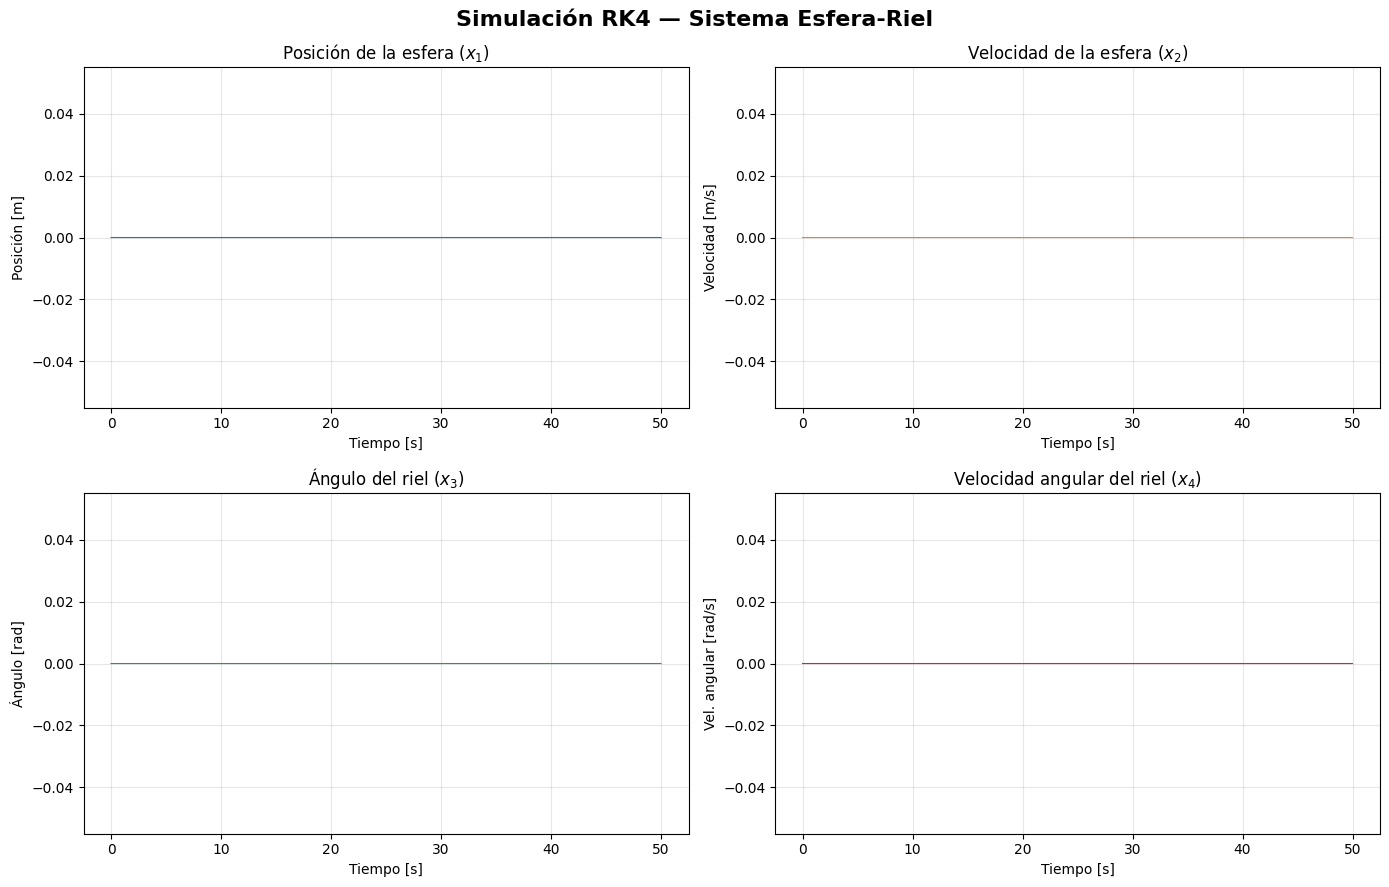

In [27]:
#GRAFICAS ESTATICAS
fig_static, axs = plt.subplots(2, 2, figsize=(14, 9))
fig_static.suptitle('Simulación RK4 — Sistema Esfera-Riel', fontsize=16, fontweight='bold')

axs[0, 0].plot(t_valores, x_valores[:, 0], color='tab:blue', linewidth=0.8)
axs[0, 0].set_title('Posición de la esfera ($x_1$)')
axs[0, 0].set_xlabel('Tiempo [s]')
axs[0, 0].set_ylabel('Posición [m]')
axs[0, 0].grid(True, alpha=0.3)

axs[0, 1].plot(t_valores, x_valores[:, 1], color='tab:orange', linewidth=0.8)
axs[0, 1].set_title('Velocidad de la esfera ($x_2$)')
axs[0, 1].set_xlabel('Tiempo [s]')
axs[0, 1].set_ylabel('Velocidad [m/s]')
axs[0, 1].grid(True, alpha=0.3)

axs[1, 0].plot(t_valores, x_valores[:, 2], color='tab:green', linewidth=0.8)
axs[1, 0].set_title('Ángulo del riel ($x_3$)')
axs[1, 0].set_xlabel('Tiempo [s]')
axs[1, 0].set_ylabel('Ángulo [rad]')
axs[1, 0].grid(True, alpha=0.3)

axs[1, 1].plot(t_valores, x_valores[:, 3], color='tab:red', linewidth=0.8)
axs[1, 1].set_title('Velocidad angular del riel ($x_4$)')
axs[1, 1].set_xlabel('Tiempo [s]')
axs[1, 1].set_ylabel('Vel. angular [rad/s]')
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('respuesta_temporal_esfera_riel_rk4.png', dpi=150)